In [40]:
import sys
sys.path.append("/home/al/Documents/code/generate_responses/generator")

import numpy as np
from itertools import chain

from generators import PoissonSpikeGenerator
from responses import ResponseConfig, make_response_data, ResponseDetector
from responses.response_tests import WilcoxonTest

from plot_utils import *

(<Figure size 600x400 with 4 Axes>,
 {'raster': <Axes: label='raster'>,
  'isi': <Axes: label='isi', xlabel='ISI [s]', ylabel='count'>,
  'text': <Axes: label='text'>,
  'r_t': <Axes: label='r_t', xlabel='time [ms]', ylabel='fr [Hz]'>})

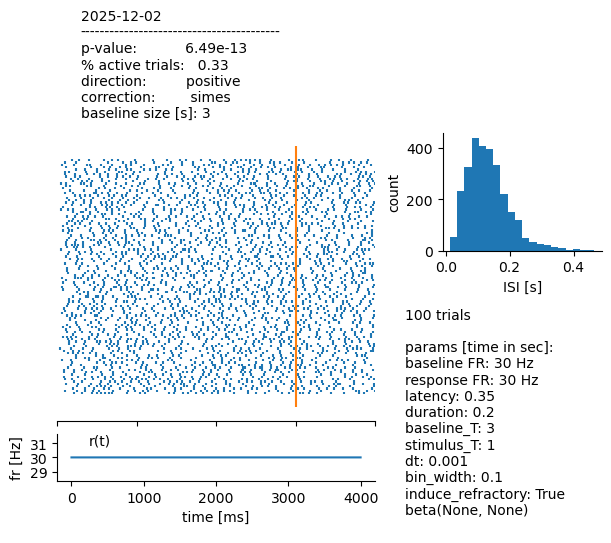

In [55]:
baseline_fr = 30
response_fr = 30
latency = 0.35
duration = 0.2
dt = 0.001
baseline_T = 3
stimulus_T = 1

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 100

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": 1,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": False,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)


SpikeSummaryFigure(trial_activity, generator, detector, ).build()

np.float64(0.0)

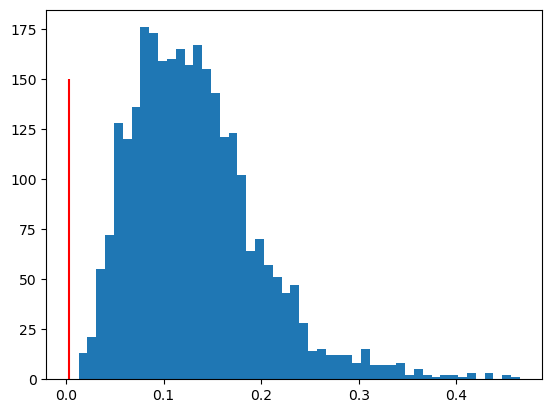

In [57]:
isis = np.array(list(chain.from_iterable([np.diff(t) for t in trial_activity])))
plt.hist(isis, bins=50)
plt.vlines(0.003, ymin=0, ymax=150, colors="red")

sum(isis < 0.003) / len(isis) * 100